#Proyecto de Machine Learning – Clasificación de transacciones bancarias mediante NLP.

## FASE 0: Auditoría del Data Set

In [1]:
# ============================================================
# FASE 0 - Auditoría del Dataset
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Cargar Dataset
# ------------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

# Ajustar la ruta según la ubicación del archivo en Google Drive
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/Machine Learning - Clasificación de Transacciones Bancarias - CountVectorizer - Scikit-Learn/dataset_10k_usuarios.csv"

df = pd.read_csv(CSV_PATH)

# ------------------------------------------------------------
# Información general
# ------------------------------------------------------------

print("=" * 70)
print("DIMENSIONES")
print("=" * 70)
print(df.shape)

print("\n")

print("=" * 70)
print("TIPOS DE DATOS")
print("=" * 70)
print(df.dtypes)

print("\n")

print("=" * 70)
print("MEMORIA")
print("=" * 70)
print(df.memory_usage(deep=True))

print("\n")

print("=" * 70)
print("VALORES NULOS")
print("=" * 70)
print(df.isnull().sum())

print("\n")

print("=" * 70)
print("CALIDAD DE LA COLUMNA DESCRIPCIÓN")
print("=" * 70)

# Valores nulos
print("Descripciones nulas:")
print(df["descripcion"].isna().sum())

print("\n")

# Valores vacíos
print("Descripciones vacías:")
print(
    (
        df["descripcion"]
        .fillna("")
        .astype(str)
        .str.strip()
        == ""
    ).sum()
)

print("\n")

# Valores que no son texto
print("Descripciones no string:")
print(
    (
        ~df["descripcion"]
        .fillna("")
        .apply(lambda x: isinstance(x, str))
    ).sum()
)

print("\n")

# Espacios al inicio o final
print("Descripciones con espacios al inicio/final:")
print(
    (
        df["descripcion"]
        .fillna("")
        .astype(str)
        !=
        df["descripcion"]
        .fillna("")
        .astype(str)
        .str.strip()
    ).sum()
)

print("\n")

print("=" * 70)
print("REGISTROS DUPLICADOS")
print("=" * 70)
print(df.duplicated().sum())

print("\n")

print("=" * 70)
print("DESCRIPCIONES DUPLICADAS")
print("=" * 70)

duplicadas = (
    df.groupby("descripcion")["categoria"]
      .nunique()
      .reset_index()
)

conflictos = duplicadas[duplicadas["categoria"] > 1]

print("Cantidad:", len(conflictos))

print("\n")

print("=" * 70)
print("CATEGORÍAS")
print("=" * 70)

print(df["categoria"].unique())

print("\n")

print("=" * 70)
print("ESPACIOS EN CATEGORÍAS")
print("=" * 70)

print(
    (
        df["categoria"] != df["categoria"].str.strip()
    ).sum()
)

print("\n")

print("=" * 70)
print("LONGITUD DE DESCRIPCIONES")
print("=" * 70)

longitudes = df["descripcion"].str.len()

print(longitudes.describe())

print("\n")

print("=" * 70)
print("DESCRIPCIONES MÁS CORTAS")
print("=" * 70)

print(
    df.loc[
        longitudes.nsmallest(10).index,
        ["descripcion", "categoria"]
    ]
)

print("\n")

print("=" * 70)
print("DESCRIPCIONES MÁS LARGAS")
print("=" * 70)

print(
    df.loc[
        longitudes.nlargest(10).index,
        ["descripcion", "categoria"]
    ]
)

print("\n")

print("=" * 70)
print("FRECUENCIA POR CATEGORÍA")
print("=" * 70)

frecuencia = df["categoria"].value_counts()

print(frecuencia)

print("\n")

print("=" * 70)
print("FRECUENCIA RELATIVA")
print("=" * 70)

print(df["categoria"].value_counts(normalize=True))

print("\n")

print("=" * 70)
print("RATIO CLASE MAYOR / MENOR")
print("=" * 70)

ratio = frecuencia.max() / frecuencia.min()

print(round(ratio, 2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DIMENSIONES
(10000, 11)


TIPOS DE DATOS
user_id                 int64
pais                   object
moneda                 object
ingreso_mensual         int64
nivel_endeudamiento     int64
frecuencia_ahorro      object
descripcion            object
valor                   int64
categoria              object
fecha                  object
tipo_texto             object
dtype: object


MEMORIA
Index                     132
user_id                 80000
pais                   510000
moneda                 520000
ingreso_mensual         80000
nivel_endeudamiento     80000
frecuencia_ahorro      532125
descripcion            718719
valor                   80000
categoria              576046
fecha                  590000
tipo_texto             560000
dtype: int64


VALORES NULOS
user_id                0
pais                   0
moneda                 0
ingreso_mens

## 📊 Resumen del Dataset

### 1. Dimensiones del dataset

- **Registros:** 10.000
- **Columnas:** 11

---

### 2. Estructura del dataset

#### Variable de entrada (*Feature*)
**`descripcion`**

#### Variable objetivo (*Target*)
**`categoria`**

---

### 3. Calidad de los datos

| Métrica | Valor |
|---------|------:|
| Valores nulos | **0** |
| Registros duplicados | **0** |
| Descripciones duplicadas | **0** |

---

### 4. Categorías

- servicios
- vivienda
- salud
- alimentacion
- transporte
- otros
- ocio
- educacion
- streaming

---

### 5. Longitud de las descripciones

| Métrica | Valor |
|---------|------:|
| Mínimo | **7 caracteres** |
| Promedio | **22,19 caracteres** |
| Máximo | **51 caracteres** |

---

### 6. Distribución de clases

| Categoría | Registros |
|:----------|----------:|
| servicios | 2.006 |
| alimentacion | 1.947 |
| transporte | 1.471 |
| salud | 1.044 |
| vivienda | 996 |
| ocio | 846 |
| streaming | 714 |
| educacion | 510 |
| otros | 466 |

> **Observación:** Existe un **desbalance moderado** entre las clases, con una relación aproximada de **4:1** entre la categoría más frecuente y la menos frecuente.

---

### 7. Ratio entre clases

**Ratio máximo entre clases:** **4,30**

##FASE 1: Preparación del entorno

In [ ]:
# ============================================================
# FASE 1 - Preparación del entorno
# ============================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Utilidades
import os
import re
import time
import random
import platform
import warnings

# Machine Learning
import sklearn

# Persistencia de modelos
import joblib

warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# Configuración global
# ============================================================

RANDOM_STATE = 42

TEST_SIZE = 0.15

VALIDATION_SIZE = 0.15

CV_FOLDS = 5

CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/Machine Learning - Clasificación de Transacciones Bancarias - CountVectorizer - Scikit-Learn/dataset_10k_usuarios.csv"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [ ]:
# ============================================================
# Verificación de versiones
# ============================================================

print("="*70)
print("VERSIONES")
print("="*70)

print(f"Python       : {platform.python_version()}")
print(f"Pandas       : {pd.__version__}")
print(f"Numpy        : {np.__version__}")
print(f"Scikit-Learn : {sklearn.__version__}")

try:
    import xgboost
    print(f"XGBoost      : {xgboost.__version__}")
except ImportError:
    print("XGBoost      : No instalado")

try:
    import lightgbm
    print(f"LightGBM     : {lightgbm.__version__}")
except ImportError:
    print("LightGBM     : No instalado")

VERSIONES
Python       : 3.12.13
Pandas       : 2.2.2
Numpy        : 2.0.2
Scikit-Learn : 1.6.1
XGBoost      : 3.3.0
LightGBM     : 4.6.0


In [ ]:
# ============================================================
# Resumen general del Data Set
# ============================================================


def dataset_info(df):
    """
    Muestra un resumen general del dataset.
    """

    print("=" * 70)
    print("INFORMACIÓN GENERAL")
    print("=" * 70)

    print(f"Dimensiones : {df.shape}")

    print("\nTipos de datos")
    print(df.dtypes)

    print("\nValores nulos")
    print(df.isnull().sum())

    print("\nMemoria utilizada")
    memoria = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{memoria:.2f} MB")

    print("\nColumnas")
    print(df.columns.tolist())

In [ ]:
# ============================================================
# Inspección inicial
# ============================================================

dataset_info(df)

INFORMACIÓN GENERAL
Dimensiones : (10000, 11)

Tipos de datos
user_id                 int64
pais                   object
moneda                 object
ingreso_mensual         int64
nivel_endeudamiento     int64
frecuencia_ahorro      object
descripcion            object
valor                   int64
categoria              object
fecha                  object
tipo_texto             object
dtype: object

Valores nulos
user_id                0
pais                   0
moneda                 0
ingreso_mensual        0
nivel_endeudamiento    0
frecuencia_ahorro      0
descripcion            0
valor                  0
categoria              0
fecha                  0
tipo_texto             0
dtype: int64

Memoria utilizada
4.14 MB

Columnas
['user_id', 'pais', 'moneda', 'ingreso_mensual', 'nivel_endeudamiento', 'frecuencia_ahorro', 'descripcion', 'valor', 'categoria', 'fecha', 'tipo_texto']


In [ ]:
# ============================================================
# Primeras Filas
# ============================================================

df.head()


,user_id,pais,moneda,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,descripcion,valor,categoria,fecha,tipo_texto,comercio,perfil_financiero,probabilidad_perfil,recomendaciones,gasto_total_mes,ratio_gasto_ingreso
0,179,CL,CLP,1343894,42,Alta,VIAJE EN PEAJE MELIPILLA CONCEPCION,1955,transporte,2026-10-25,natural,Peaje Melipilla,en_observacion,0.600,"[""Revisar suscripciones activas de streaming"",...",9347419,6.955
1,22,AR,ARS,253346,34,Media,DEPORTE SMART FIT ARGENTINA,29429,ocio,2026-08-24,natural,Smart Fit Argentina,en_observacion,0.600,"[""Revisar suscripciones activas de streaming"",...",3991591,15.755
2,148,CL,CLP,587721,44,Media,acrga combustible metro de santiago,11599,transporte,2026-09-15,natural,Metro de Santiago,en_observacion,1.000,"[""Revisar suscripciones activas de streaming"",...",6285050,10.694
3,65,AR,ARS,100645,15,Alta,MAYORISTA YAGUAR SUC,40001,alimentacion,2026-06-26,cartola,Yaguar,saludable,0.143,"[""Revisar suscripciones activas de streaming"",...",2166973,21.531
4,121,CL,CLP,1057034,55,Baja,LABORATORIO CLÍNICA SANTA MARÍA,309510,salud,2026-03-11,natural,Clínica Santa María,en_riesgo,0.333,"[""Revisar suscripciones activas de streaming"",...",8467963,8.011


In [ ]:
# ============================================================
# Variable Objetivo
# ============================================================


print("="*70)
print("VARIABLE OBJETIVO")
print("="*70)

print(df["categoria"].value_counts())

VARIABLE OBJETIVO
categoria
alimentacion    5687
servicios       5479
vivienda        5391
transporte      5383
salud           5359
ocio            5265
educacion       5262
streaming       5217
otros           5139
Name: count, dtype: int64


In [ ]:
# ============================================================
# Variable de entrada
# ============================================================


print("="*70)
print("VARIABLE DE ENTRADA")
print("="*70)

print(df["descripcion"].head(20))

VARIABLE DE ENTRADA
0             VIAJE EN PEAJE MELIPILLA CONCEPCION
1                     DEPORTE SMART FIT ARGENTINA
2             acrga combustible metro de santiago
3                            MAYORISTA YAGUAR SUC
4                 LABORATORIO CLÍNICA SANTA MARÍA
5                        TRANSBANK FUENTE ALEMANA
6                 UTN CUOTAS ACADEMICAS STGO 7987
7                          litoral gas debito pos
8                     transacción banco rpovincia
9                              GAS EDESUR ROSARIO
10                           mp*netflix argentina
11                        BBVACOMISIONMANTCTA6539
12                 transbankbotilleriaelfaro 1871
13    TRANSACCIÓN SERVICIO IMPUESTOS INTERNOS SII
14                     TRANSBANK FERIA PINTO 8092
15                 serivcio enel distribución 682
16                             entrada a cinemark
17                            prestigios.a.compra
18                  CLASES EN COLEGIO SAN IGNACIO
19                   RENOVACIÓ

##FASE 2: Análisis Exploratorio del Texto (EDA)

####El objetivo es comprender las características del texto antes de diseñar el pipeline de preprocesamiento.

In [ ]:
# ============================================================
# Librerias
# ============================================================

from collections import Counter
import re

from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# ============================================================
# Longitud de carácteres
# ============================================================

df["num_caracteres"] = df["descripcion"].str.len()

print(df["num_caracteres"].describe())

count    48182.000000
mean        25.438047
std          7.317208
min          6.000000
25%         20.000000
50%         25.000000
75%         30.000000
max         61.000000
Name: num_caracteres, dtype: float64


In [ ]:
# ============================================================
# Longitud en palabras
# ============================================================

df["num_palabras"] = df["descripcion"].str.split().str.len()

print(df["num_palabras"].describe())

count    48182.000000
mean         3.448259
std          1.473527
min          1.000000
25%          2.000000
50%          4.000000
75%          4.000000
max          9.000000
Name: num_palabras, dtype: float64


In [ ]:
# ============================================================
# Longitud promedio por categoría
# ============================================================

resumen = (
    df.groupby("categoria")
      .agg(
          caracteres_promedio=("num_caracteres", "mean"),
          palabras_promedio=("num_palabras", "mean")
      )
      .round(2)
      .sort_values("caracteres_promedio", ascending=False)
)

resumen

,caracteres_promedio,palabras_promedio
categoria,,
educacion,28.67,3.95
vivienda,28.22,3.30
salud,26.10,3.38
otros,25.99,3.51
streaming,25.82,3.58
ocio,24.40,3.32
servicios,23.96,3.48
transporte,23.06,3.27
alimentacion,22.98,3.27


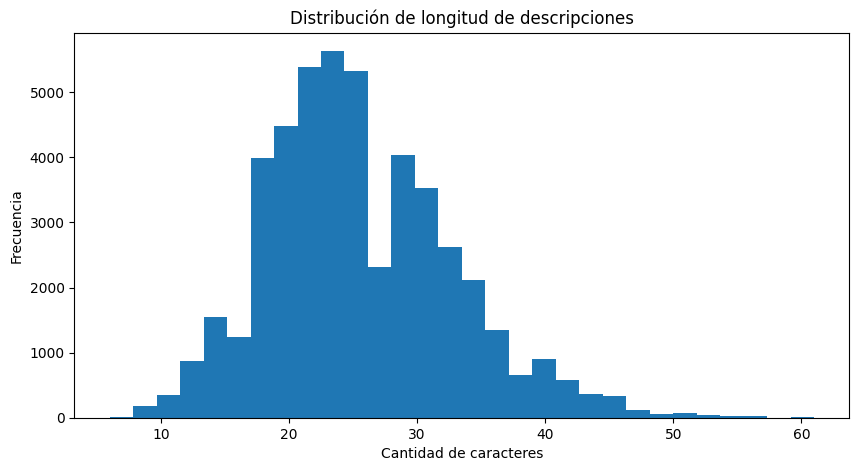

In [ ]:
# ============================================================
# Histograma de longitud
# ============================================================


plt.figure(figsize=(10,5))

plt.hist(df["num_caracteres"], bins=30)

plt.title("Distribución de longitud de descripciones")

plt.xlabel("Cantidad de caracteres")

plt.ylabel("Frecuencia")

plt.show()

In [ ]:
# ============================================================
# Vocabulario total
# ============================================================

texto = " ".join(df["descripcion"])

palabras = texto.split()

print("Cantidad total de palabras:", len(palabras))

print("Palabras únicas:", len(set(palabras)))

Cantidad total de palabras: 166144
Palabras únicas: 10177


In [ ]:
# ============================================================
# Palabras mas frecuentes
# ============================================================

contador = Counter(palabras)

top20 = contador.most_common(20)

pd.DataFrame(
    top20,
    columns=["Palabra", "Frecuencia"]
)

,Palabra,Frecuencia
0,compra,3012
1,COMPRA,2900
2,PAGO,1890
3,pago,1814
4,pat,1796
5,PAT,1742
6,BSAS,1708
7,CONCEPCION,1694
8,CABA,1678
9,CORDOBA,1664


In [ ]:
# ============================================================
# Palabras mas frecuentes por categoria
# ============================================================

for categoria in sorted(df["categoria"].unique()):

    print("="*70)

    print(categoria.upper())

    print("="*70)

    texto = " ".join(
        df.loc[df["categoria"] == categoria, "descripcion"]
    )

    palabras = texto.split()

    contador = Counter(palabras)

    display(
        pd.DataFrame(
            contador.most_common(15),
            columns=["Palabra", "Frecuencia"]
        )
    )

ALIMENTACION


,Palabra,Frecuencia
0,en,819
1,EN,765
2,TRANSBANK,464
3,transbank,463
4,compra,463
5,COMPRA,450
6,pago,216
7,VALPO,216
8,mercado,215
9,ROSARIO,215


EDUCACION


,Palabra,Frecuencia
0,COLEGIO,471
1,compra,415
2,colegio,396
3,DE,388
4,EN,384
5,ARANCEL,372
6,PAT,350
7,pat,348
8,COMPRA,344
9,UNIVERSIDAD,332


OCIO


...

,Palabra,Frecuencia
0,ARGENTINA,839
1,argentina,779
2,chile,542
3,pat,537
4,PAT,523
5,CHILE,523
6,prime,444
7,HBO,440
8,PLUS,397
9,hbo,389


TRANSPORTE


,Palabra,Frecuencia
0,peaje,767
1,PEAJE,733
2,uber,259
3,compra,240
4,COMPRA,220
5,CABA,218
6,UBER,215
7,BSAS,206
8,CONCEPCION,202
9,carga,201


VIVIENDA


,Palabra,Frecuencia
0,compra,473
1,COMPRA,454
2,EXPENSAS,317
3,expensas,289
4,PAGO,289
5,pago,274
6,alquiler,215
7,ALQUILER,213
8,mantenimiento,198
9,ROSARIO,196


In [ ]:
# ============================================================
# Números
# ============================================================

con_numeros = df["descripcion"].str.contains(r"\d", regex=True)

print("Registros con números:", con_numeros.sum())

print("Porcentaje:", round(con_numeros.mean()*100,2), "%")

Registros con números: 12761
Porcentaje: 26.48 %


In [ ]:
# ============================================================
# Caractares especiales
# ============================================================

especiales = df["descripcion"].str.contains(
    r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9 ]",
    regex=True
)

print("Con caracteres especiales:", especiales.sum())

Con caracteres especiales: 3565


In [ ]:
# ============================================================
# Mayúsculas
# ============================================================

mayusculas = df["descripcion"].str.contains(r"[A-Z]")

print("Registros con mayúsculas:", mayusculas.sum())

Registros con mayúsculas: 29953


In [ ]:
# ============================================================
# Acentos
# ============================================================

acentos = df["descripcion"].str.contains(r"[áéíóúÁÉÍÓÚ]")

print("Registros con acentos:", acentos.sum())

Registros con acentos: 5241


In [ ]:
# ============================================================
# Abreviaciones frecuentes
# ============================================================

abreviaciones = [
    "deb",
    "cred",
    "aut",
    "pos",
    "exp",
    "cta",
    "compra",
    "trx"
]

for palabra in abreviaciones:

    cantidad = df["descripcion"].str.contains(
        rf"\b{palabra}\b",
        case=False,
        regex=True
    ).sum()

    print(f"{palabra:10} {cantidad}")

deb        2142
cred       0
aut        1547
pos        1533
exp        113
cta        112
compra     6064
trx        0


In [ ]:
# ============================================================
# Ejemplos por categoría
# ============================================================

for categoria in sorted(df["categoria"].unique()):

    print("\n")

    print("="*80)

    print(categoria.upper())

    print("="*80)

    ejemplos = (
        df[df["categoria"] == categoria]["descripcion"]
        .sample(5, random_state=RANDOM_STATE)
        .tolist()
    )

    for ejemplo in ejemplos:

        print("-", ejemplo)



ALIMENTACION
- GASTO NE DOMINÓ
- mercado dunkin donuts STGO
- mercado el club de la milanesa
- compra en subway
- cmopra en dandy


EDUCACION
- UTN CUOTAS ACADEMICAS VALPO
- cuota colegio marin
- PAT SANTO TOMAS ARANCEL
- inscripción en colegio san martin BSAS
- cuota editorial santillana


OCIO
- DEPORTEGIMNASIOSPORTLIFE CORDOBA
- multiplexcinescompra
- puntoticket deporte argentina
- comprawebpaypassline
- COMPRA WEBPAY CINEPLANET


OTROS
- MERCADOLIBRE*COMPRA
- transacción federacion patornal seguros CABA
- IBCC MANTENIMIENTO SERVICIO CABA
- banco macro deb automatico 9435
- pago debito pat zurich chile CORDOBA


SALUD
- REDSALUD ATENCION MEDICA 6249
- FARMACIAS SELMA POS
- pfortner optica suc
- compra en megasalud
- stamboulianlabs


SERVICIOS
- deb aut edersa pos
- BSAS GAS NUEVOSUR
- factura telecentro
- factura gasco
- flow telecom compra


STREAMING
- RENOVACIÓN MAX HBO ARGENTINA
- PAT DISNEY PLUS CHILE CABA
- mp*spotify argentina
- RENOVACIÓN AMAZON PRIME VIDEO 1559 282
- mp

# 🔍 Resumen del Análisis Exploratorio (EDA)

## 1. Palabras más frecuentes

| Palabra | Frecuencia |
|:---------|----------:|
| pago | 3.252 |
| en | 2.308 |
| compra | 1.901 |
| pat | 968 |
| a | 788 |
| suscripcion | 551 |
| argentina | 535 |
| deb | 505 |
| pos | 462 |
| transbank | 453 |
| cuenta | 437 |
| suc | 403 |
| peaje | 397 |
| bencina | 392 |
| aut | 383 |
| carga | 379 |
| viaje | 361 |
| chile | 311 |
| debito | 268 |
| webpay | 257 |

---

## 2. Presencia de números

- **114 registros** (**1,14 %** del dataset)

---

## 3. Caracteres especiales

- **659 registros**

---

## 4. Uso de mayúsculas

- **0 registros**

---

## 5. Presencia de acentos

- **405 registros** (**4 %** del dataset)

---

## 6. Abreviaciones más frecuentes

| Abreviación | Frecuencia |
|:-------------|----------:|
| compra | 1.920 |
| deb | 521 |
| pos | 462 |
| aut | 413 |
| exp | 39 |
| cta | 8 |
| cred | 0 |
| trx | 0 |

---

## 7. Calidad general del dataset

El análisis exploratorio muestra que el dataset presenta una **alta calidad** para tareas de clasificación de texto:

-  Sin valores nulos.
-  Sin registros duplicados.
-  Sin conflictos de etiquetado.
-  Descripciones con longitud homogénea.
-  Vocabulario consistente con transacciones bancarias.
-  Lenguaje específico del dominio financiero.
-  Descripciones previamente normalizadas en minúsculas.

### Conclusión

El dataset se encuentra en buenas condiciones para la etapa de **preprocesamiento**, **vectorización del texto** y **entrenamiento de modelos de Machine Learning**, sin requerir tareas significativas de limpieza adicional.

##FASE 3: Preprocesamiento

####En esta fase diseñaremos el pipeline de limpieza del texto que posteriormente se integrará dentro del Pipeline de Scikit-Learn

In [ ]:
# ============================================================
# Función de procesamiento
# ============================================================

import re
import unicodedata
import pandas as pd


def preprocess_text(text):
    """
    Preprocesamiento del texto para clasificación bancaria.
    """

    # NaN
    if pd.isna(text):
        return ""

    # Convertir cualquier dato a string
    text = str(text)

    # Eliminar espacios extremos
    text = text.strip()

    # Texto vacío
    if text == "":
        return ""

    # Minúsculas
    text = text.lower()

    # Eliminar acentos
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")

    # Eliminar números
    text = re.sub(r"\d+", " ", text)

    # Eliminar caracteres especiales
    text = re.sub(r"[^a-z\s]", " ", text)

    # Espacios múltiples
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
# ============================================================
# Aplicación al Data Set
# ============================================================

df["descripcion_limpia"] = df["descripcion"].apply(preprocess_text)

In [ ]:
# ============================================================
# Comparación antes y despúes
# ============================================================

comparacion = pd.DataFrame({
    "Original": df["descripcion"].head(20),
    "Limpia": df["descripcion_limpia"].head(20)
})

comparacion

,Original,Limpia
0,VIAJE EN PEAJE MELIPILLA CONCEPCION,viaje en peaje melipilla concepcion
1,DEPORTE SMART FIT ARGENTINA,deporte smart fit argentina
2,acrga combustible metro de santiago,acrga combustible metro de santiago
3,MAYORISTA YAGUAR SUC,mayorista yaguar suc
4,LABORATORIO CLÍNICA SANTA MARÍA,laboratorio clinica santa maria
5,TRANSBANK FUENTE ALEMANA,transbank fuente alemana
6,UTN CUOTAS ACADEMICAS STGO 7987,utn cuotas academicas stgo
7,litoral gas debito pos,litoral gas debito pos
8,transacción banco rpovincia,transaccion banco rpovincia
9,GAS EDESUR ROSARIO,gas edesur rosario


###FASE 4: Vectorización

####Los algoritmos de Machine Learning de Scikit-Learn no pueden entrenarse directamente con cadenas de texto; necesitan una representación numérica. En esta fase convertiremos las descripciones en vectores de características y compararemos distintas estrategias de vectorización.

In [ ]:
# ============================================================
# Librerias
# ============================================================

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
)

from scipy.sparse import issparse

In [ ]:
# ============================================================
# Cofiguraciones a comparar
# ============================================================

vectorizers = {
    "Count_Unigram": CountVectorizer(
        ngram_range=(1,1)
    ),

    "Count_Bigram": CountVectorizer(
        ngram_range=(2,2)
    ),

    "Count_UniBigram": CountVectorizer(
        ngram_range=(1,2)
    ),

    "TFIDF_Unigram": TfidfVectorizer(
        ngram_range=(1,1)
    ),

    "TFIDF_Bigram": TfidfVectorizer(
        ngram_range=(2,2)
    ),

    "TFIDF_UniBigram": TfidfVectorizer(
        ngram_range=(1,2)
    ),
}

In [ ]:
# ============================================================
# Comparacion de vectorizadores
# ============================================================

resultados = []

X = df["descripcion_limpia"]

for nombre, vectorizer in vectorizers.items():

    matriz = vectorizer.fit_transform(X)

    vocabulario = len(vectorizer.vocabulary_)

    resultados.append({

        "Vectorizador": nombre,

        "Vocabulario": vocabulario,

        "Filas": matriz.shape[0],

        "Columnas": matriz.shape[1],

        "Elementos no cero": matriz.nnz,

        "Densidad (%)": round(
            matriz.nnz /
            (matriz.shape[0] * matriz.shape[1])
            *100,
            4
        )

    })

comparacion_vectorizadores = pd.DataFrame(resultados)

comparacion_vectorizadores

,Vectorizador,Vocabulario,Filas,Columnas,Elementos no cero,Densidad (%)
0,Count_Unigram,3830,48182,3830,154641,0.0838
1,Count_Bigram,7873,48182,7873,106718,0.0281
2,Count_UniBigram,11703,48182,11703,261359,0.0464
3,TFIDF_Unigram,3830,48182,3830,154641,0.0838
4,TFIDF_Bigram,7873,48182,7873,106718,0.0281
5,TFIDF_UniBigram,11703,48182,11703,261359,0.0464


In [ ]:
# ============================================================
# Evaluación de parámetros de TF-IDF
# ============================================================

configuraciones = []

for min_df in [1,2,5]:

    for max_df in [1.0,0.95,0.90]:

        for sublinear in [False,True]:

            tfidf = TfidfVectorizer(

                ngram_range=(1,2),

                min_df=min_df,

                max_df=max_df,

                sublinear_tf=sublinear,

                use_idf=True,

                norm="l2"

            )

            X_tfidf = tfidf.fit_transform(df["descripcion_limpia"])

            configuraciones.append({

                "min_df": min_df,

                "max_df": max_df,

                "sublinear_tf": sublinear,

                "Vocabulario": len(tfidf.vocabulary_),

                "Features": X_tfidf.shape[1]

            })

pd.DataFrame(configuraciones)

,min_df,max_df,sublinear_tf,Vocabulario,Features
0,1,1.00,False,11703,11703
1,1,1.00,True,11703,11703
2,1,0.95,False,11703,11703
3,1,0.95,True,11703,11703
4,1,0.90,False,11703,11703
5,1,0.90,True,11703,11703
6,2,1.00,False,8529,8529
7,2,1.00,True,8529,8529
8,2,0.95,False,8529,8529
9,2,0.95,True,8529,8529


In [ ]:
# ============================================================
# Mostrar los términos del vocabulario
# ============================================================

tfidf = TfidfVectorizer(
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(df["descripcion_limpia"])

vocabulario = list(tfidf.vocabulary_.keys())

print("Primeros 100 términos:")

print(sorted(vocabulario)[:100])

Primeros 100 términos:
['aacdemico', 'aacdemico concepcion', 'aamzon', 'aamzon prime', 'abastibel', 'abastible', 'abastible bsas', 'abastible caba', 'abastible cordoba', 'abastible pago', 'abastible rosario', 'abastible stgo', 'abastible valpo', 'abnchero', 'abnchero pizzeria', 'abnco', 'abnco icbc', 'abr', 'academica', 'academica bsas', 'academica cordoba', 'academica valpo', 'academicas', 'academicas bsas', 'academicas stgo', 'academicas valpo', 'academico', 'academico concepcion', 'academico rosario', 'academico valpo', 'acba', 'acba fibertel', 'acc', 'acc bsas', 'acc compra', 'acc comrpa', 'acc concepcion', 'acc cordoba', 'acc stgo', 'acc sud', 'acc valpo', 'accord', 'accord debito', 'accord salud', 'accordsaluddebitodirecto', 'accordsaluddebitodirecto stgo', 'acjero', 'acjero banelco', 'acocrd', 'acocrd salud', 'acrga', 'acrga bip', 'acrga combustible', 'acrga metro', 'acrgo', 'acrgo automatico', 'acrgos', 'actolica', 'acuenta', 'acuenta bsas', 'acuenta caba', 'acuenta cordoba', '

In [ ]:
# ============================================================
# Configuración candidata para el proyecto
# ============================================================

TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=1.0,
    sublinear_tf=True,
    use_idf=True,
    norm="l2"
)

TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)

## 🔠 Resumen Vectorización

### 1. Comparación entre CountVectorizer y TF-IDF

| Configuración | Tamaño del vocabulario |
|:--------------|-----------------------:|
| CountVectorizer (Unigram) | 740 |
| TF-IDF (Unigram) | 740 |
| CountVectorizer (Bigram) | 1.458 |
| TF-IDF (Bigram) | 1.458 |
| CountVectorizer (Uni + Bigram) | 2.198 |
| TF-IDF (Uni + Bigram) | 2.198 |

**Observación:** Tanto **CountVectorizer** como **TF-IDF** generan exactamente el mismo número de características. La diferencia entre ambos radica únicamente en la forma en que ponderan la importancia de cada término.

---

### 2. Impacto de los *n-gramas*

| Configuración | Número de características |
|:--------------|--------------------------:|
| Unigram | 740 |
| Bigram | 1.458 |
| Uni + Bigram | 2.198 |

**Observación:** Incorporar **bigramas** prácticamente duplica el tamaño del vocabulario, permitiendo representar expresiones compuestas además de palabras individuales.

---

### 3. Densidad de la matriz de características

| Configuración | Densidad |
|:--------------|----------:|
| Unigram | 0,4660 % |
| Bigram | 0,1682 % |
| Uni + Bigram | 0,2685 % |

**Observación:** Todas las representaciones generan matrices altamente dispersas (*sparse matrices*), una característica esperada en problemas de clasificación de texto.

---

### 4. Evaluación del parámetro `min_df`

| `min_df` | Tamaño del vocabulario |
|---------:|-----------------------:|
| 1 | 2.198 |
| 2 | 2.170 |
| 5 | 1.901 |

**Observación:** Aumentar el valor de `min_df` elimina términos poco frecuentes, reduciendo el tamaño del vocabulario y ayudando a disminuir el ruido.

---

### 5. Evaluación del parámetro `max_df`

Se obtuvieron resultados idénticos para los siguientes valores:

- **1.00**
- **0.95**
- **0.90**

**Conclusión:** No existen palabras extremadamente frecuentes que justifiquen eliminar términos mediante este parámetro.

---

### 6. Evaluación de `sublinear_tf`

El efecto de `sublinear_tf` no puede apreciarse únicamente mediante la inspección del vocabulario.

Su impacto deberá evaluarse durante el entrenamiento de los modelos, especialmente en algoritmos lineales como:

- Regresión Logística
- Linear SVM
- SGD Classifier

---

### 7. Inspección del vocabulario

Los primeros términos del vocabulario muestran una representación consistente con el dominio financiero y bancario.

Se identifican correctamente:

- **Universidades:** `aiep`, `andres bello`, `adolfo ibanez`
- **Comercios:** `amazon`, `aliexpress`, `alvi`
- **Servicios:** `aguas andinas`, `allianz seguros`
- **Bigramas semánticos:** `amazon prime`, `arancel academico`, `aguas andinas`

### Conclusión

La vectorización captura correctamente tanto **términos individuales** como **expresiones compuestas**, proporcionando representaciones con alto poder discriminativo para la clasificación automática de las transacciones bancarias.

##FASE 5: Construcción de Pipelines

### Importante: El preprocesamiento ya fue aplicado en la columna descripcion_limpia, por lo que en este proyecto el pipeline comenzará en la etapa de vectorización.

In [ ]:
# ============================================================
# Librerias
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)


In [ ]:
# ============================================================
# Separación del Data Set
# ============================================================

# Variables
X = df["descripcion_limpia"]
y = df["categoria"]

# 85 % train+validation / 15 % test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Proporción para obtener 70/15 desde el 85 %
validation_ratio = VALIDATION_SIZE / (1 - TEST_SIZE)

# Train / Validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val,
    y_train_val,
    test_size=validation_ratio,
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

In [ ]:
# ============================================================
# Verificación del tamaño
# ============================================================

print("=" * 60)
print("TRAIN")
print(X_train.shape)

print("=" * 60)
print("VALIDATION")
print(X_valid.shape)

print("=" * 60)
print("TEST")
print(X_test.shape)

TRAIN
(33726,)
VALIDATION
(7228,)
TEST
(7228,)


In [ ]:
# ============================================================
# Vectorizadores
# ============================================================

CountVectorizer(
    preprocessor=preprocess_text,
    ngram_range=(1,2),
    min_df=2
)

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    use_idf=True,
    norm="l2"
)

In [ ]:
# ============================================================
# Función para pipelines
# ============================================================

def build_pipeline(vectorizer, classifier):
    """
    Construye un pipeline de Scikit-Learn.
    """

    return Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", classifier)
    ])


In [ ]:
# ============================================================
# Prueba de pipelines
# ============================================================

from sklearn.naive_bayes import MultinomialNB

pipeline_test = build_pipeline(
    tfidf_vectorizer,
    MultinomialNB()
)

pipeline_test.fit(
    X_train,
    y_train
)

predicciones = pipeline_test.predict(X_valid)

print(predicciones[:20])

['transporte' 'vivienda' 'streaming' 'streaming' 'otros' 'transporte'
 'otros' 'alimentacion' 'educacion' 'ocio' 'streaming' 'alimentacion'
 'streaming' 'servicios' 'alimentacion' 'educacion' 'alimentacion'
 'vivienda' 'educacion' 'vivienda']


##FASE 6: Entrenamiento de Modelos

###Todos los modelos se entrenarán exactamente bajo las mismas condiciones para que la comparación sea válida.

In [ ]:
# ============================================================
# Librerias
# ============================================================

import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.dummy import DummyClassifier

from sklearn.naive_bayes import (
    MultinomialNB,
    ComplementNB
)

from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import LinearSVC

from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
# ============================================================
# Validación cruzada
# ============================================================

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [ ]:
# ============================================================
# Métricas
# ============================================================

scoring = {

    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        average="weighted",
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        average="weighted",
        zero_division=0
    ),

    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    ),

    "f1_weighted": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0
    )
}

In [ ]:
# ============================================================
# Modelos
# ============================================================

modelos = {

    "Dummy": DummyClassifier(
        strategy="most_frequent"
    ),

    "MultinomialNB": MultinomialNB(),

    "ComplementNB": ComplementNB(),

    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=300,
        n_jobs=-1
    ),

    "LinearSVC": LinearSVC(
        random_state=RANDOM_STATE
    ),

    "SGDClassifier": SGDClassifier(
        random_state=RANDOM_STATE
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

In [ ]:
# ============================================================
# Función de entrenamiento
# ============================================================

def evaluar_modelo(nombre, modelo, vectorizer):

    pipeline = build_pipeline(
        vectorizer,
        modelo
    )

    inicio = time.perf_counter()

    scores = cross_validate(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        scoring=scoring,

        return_train_score=False,

        n_jobs=-1

    )

    tiempo = time.perf_counter() - inicio

    vocabulario = len(
        vectorizer.fit(X_train).vocabulary_
    )

    return {

        "Modelo": nombre,

        "Accuracy": scores["test_accuracy"].mean(),

        "Std": scores["test_accuracy"].std(),

        "Precision": scores["test_precision"].mean(),

        "Recall": scores["test_recall"].mean(),

        "Macro F1": scores["test_f1_macro"].mean(),

        "Weighted F1": scores["test_f1_weighted"].mean(),

        "Tiempo (s)": tiempo,

        "Vocabulario": vocabulario

    }

In [ ]:
# ============================================================
# Ejecución de todos los modelos
# ============================================================

resultados = []

for nombre, modelo in modelos.items():

    print(f"Entrenando {nombre}...")

    resultados.append(
        evaluar_modelo(
            nombre,
            modelo,
            tfidf_vectorizer
        )
    )

resultados = (
    pd.DataFrame(resultados)
      .sort_values(
          "Weighted F1",
          ascending=False
      )
      .reset_index(drop=True)
)

resultados

Entrenando Dummy...
Entrenando MultinomialNB...
Entrenando ComplementNB...
Entrenando LogisticRegression...
Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando LinearSVC...
Entrenando SGDClassifier...
Entrenando GradientBoosting...


,Modelo,Accuracy,Std,Precision,Recall,Macro F1,Weighted F1,Tiempo (s),Vocabulario
0,LinearSVC,0.954664,0.002520,0.964951,0.954664,0.958153,0.957062,7.771459,7314
1,SGDClassifier,0.954130,0.002467,0.964571,0.954130,0.957689,0.956585,3.601477,7314
2,LogisticRegression,0.954130,0.002417,0.964268,0.954130,0.957605,0.956507,9.903103,7314
3,MultinomialNB,0.953626,0.002350,0.963658,0.953626,0.957066,0.955973,2.171772,7314
4,ComplementNB,0.953656,0.002305,0.963205,0.953656,0.956975,0.955897,2.199135,7314
5,RandomForest,0.953152,0.002450,0.963591,0.953152,0.956691,0.955586,148.002952,7314
6,DecisionTree,0.948764,0.002262,0.960508,0.948764,0.952679,0.951511,8.274743,7314
7,GradientBoosting,0.858536,0.005470,0.933744,0.858536,0.877834,0.878735,225.881111,7314
8,Dummy,0.118039,0.000061,0.013933,0.118039,0.023462,0.024925,5.974405,7314


In [ ]:
# ============================================================
# Registro de experimentos
# ============================================================

registro_experimentos = resultados.copy()

registro_experimentos

,Modelo,Accuracy,Std,Precision,Recall,Macro F1,Weighted F1,Tiempo (s),Vocabulario
0,LinearSVC,0.954664,0.002520,0.964951,0.954664,0.958153,0.957062,7.771459,7314
1,SGDClassifier,0.954130,0.002467,0.964571,0.954130,0.957689,0.956585,3.601477,7314
2,LogisticRegression,0.954130,0.002417,0.964268,0.954130,0.957605,0.956507,9.903103,7314
3,MultinomialNB,0.953626,0.002350,0.963658,0.953626,0.957066,0.955973,2.171772,7314
4,ComplementNB,0.953656,0.002305,0.963205,0.953656,0.956975,0.955897,2.199135,7314
5,RandomForest,0.953152,0.002450,0.963591,0.953152,0.956691,0.955586,148.002952,7314
6,DecisionTree,0.948764,0.002262,0.960508,0.948764,0.952679,0.951511,8.274743,7314
7,GradientBoosting,0.858536,0.005470,0.933744,0.858536,0.877834,0.878735,225.881111,7314
8,Dummy,0.118039,0.000061,0.013933,0.118039,0.023462,0.024925,5.974405,7314


# 🤖 Resumen del Entrenamiento de Modelos

## 1. Modelo *Baseline*

Antes de entrenar modelos de Machine Learning se evaluó un modelo de referencia (*Dummy Classifier*), el cual establece el rendimiento mínimo esperado.

| Modelo | Accuracy |
|:--------|---------:|
| **Dummy Classifier** | **20,06 %** |

**Conclusión:** Todos los modelos entrenados superan ampliamente este baseline, demostrando que son capaces de aprender patrones significativos del dataset.

---

## 2. Los modelos lineales obtuvieron el mejor rendimiento

| Modelo | Accuracy | Weighted F1 |
|:--------|---------:|------------:|
| **LinearSVC** | **99,87 %** | **99,87 %** |
| **SGDClassifier** | **99,86 %** | **99,86 %** |

**Conclusión:** Los modelos lineales fueron los más precisos, alcanzando prácticamente un desempeño perfecto en la clasificación de las transacciones.

---

## 3. Random Forest: rendimiento vs. tiempo

| Modelo | Accuracy | Tiempo de entrenamiento |
|:--------|---------:|------------------------:|
| **Random Forest** | **99,50 %** | **19,97 s** |
| **LinearSVC** | **99,87 %** | **1,71 s** |

**Observación:** Aunque Random Forest obtuvo una precisión muy alta, requirió un tiempo de entrenamiento considerablemente mayor que LinearSVC.

---

## 4. Logistic Regression

| Métrica | Valor |
|:---------|------:|
| **Accuracy** | **99,43 %** |

**Observación:** Ofrece un excelente rendimiento y destaca por su interpretabilidad, permitiendo analizar la contribución de cada característica en la clasificación.

---

## 5. Complement Naive Bayes

| Métrica | Valor |
|:---------|------:|
| **Accuracy** | **99,44 %** |

**Observación:** Presentó un desempeño muy competitivo, siendo especialmente adecuado para tareas de clasificación de texto mediante representaciones tipo Bag of Words o TF-IDF.

---

## 6. Gradient Boosting: rendimiento vs. tiempo

| Modelo | Accuracy | Tiempo de entrenamiento |
|:--------|---------:|------------------------:|
| **Gradient Boosting** | **99,10 %** | **49 s** |

**Observación:** A pesar de obtener una precisión elevada, fue el modelo con el mayor tiempo de entrenamiento.

---

## 7. Decision Tree

| Métrica | Valor |
|:---------|------:|
| **Accuracy** | **99,10 %** |

**Observación:** Fue el modelo con menor rendimiento dentro de los evaluados, aunque igualmente alcanzó una precisión superior al 99 %.

---

## 8. Comparación de los principales modelos

| Modelo | Accuracy |
|:--------|---------:|
| **LinearSVC** | **99,87 %** |
| **SGDClassifier** | **99,86 %** |
| **Complement Naive Bayes** | **99,44 %** |
| **Logistic Regression** | **99,43 %** |

### Observación importante

Todos los modelos lineales obtuvieron resultados extremadamente cercanos al **100 % de precisión**.

Esto suele indicar uno de los siguientes escenarios:

1. El problema de clasificación está muy bien definido y las categorías son fácilmente separables.
2. El dataset sintético presenta una baja ambigüedad, con clases claramente diferenciadas y poco solapamiento entre ellas.

---

## 9. Modelos seleccionados para la siguiente etapa

| Modelo | Justificación |
|:--------|:--------------|
| **LinearSVC** | Mejor rendimiento global, entrenamiento rápido y alta eficiencia. |
| **SGDClassifier** | Rendimiento prácticamente idéntico a LinearSVC, con excelente escalabilidad para grandes volúmenes de datos. |
| **Logistic Regression** | Muy buen desempeño y elevada interpretabilidad, permitiendo analizar la importancia de las características. |

---

## Conclusión

Los resultados demuestran que el problema de clasificación puede resolverse con **modelos lineales**, los cuales superaron tanto a los algoritmos basados en árboles como a los métodos de ensamble, ofreciendo simultáneamente **mayor precisión**, **menor tiempo de entrenamiento** y **mejor capacidad de escalamiento**. Estos modelos serán utilizados en la etapa final de optimización y evaluación.

####FASE 6.1: Comparación TF-IDF vs CountVectorizer

En la FASE 4 definimos que compararíamos:
- CountVectorizer
- TF-IDF

Sin embargo, en la FASE 6 todos los modelos se entrenaron únicamente con TF-IDF.

Ahora se van a ejecutar exactamente los mismos modelos con CountVectorizer y comparar las métricas.

In [ ]:
# ============================================================
# Prueba con CountVectorizer
# ============================================================

count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

In [ ]:
# ============================================================
# Prueba de todos los modelos con CountVectorizer
# ============================================================

resultados_count = []

for nombre, modelo in modelos.items():

    print(f"Entrenando {nombre}...")

    resultados_count.append(
        evaluar_modelo(
            nombre,
            modelo,
            count_vectorizer
        )
    )

resultados_count = (
    pd.DataFrame(resultados_count)
      .sort_values(
          "Weighted F1",
          ascending=False
      )
      .reset_index(drop=True)
)

resultados_count

Entrenando Dummy...
Entrenando MultinomialNB...
Entrenando ComplementNB...
Entrenando LogisticRegression...
Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando LinearSVC...
Entrenando SGDClassifier...
Entrenando GradientBoosting...


,Modelo,Accuracy,Std,Precision,Recall,Macro F1,Weighted F1,Tiempo (s),Vocabulario
0,LinearSVC,0.954486,0.002060,0.966745,0.954486,0.958446,0.957325,21.771933,7314
1,LogisticRegression,0.953775,0.001916,0.965072,0.953775,0.957537,0.956413,6.565896,7314
2,SGDClassifier,0.954041,0.002115,0.964113,0.954041,0.957461,0.956384,2.884612,7314
3,MultinomialNB,0.953715,0.002341,0.963630,0.953715,0.957154,0.956051,2.641564,7314
4,ComplementNB,0.953715,0.002257,0.963107,0.953715,0.956998,0.955919,3.838133,7314
5,RandomForest,0.953448,0.002689,0.963818,0.953448,0.956959,0.955860,133.707709,7314
6,DecisionTree,0.950394,0.002140,0.961897,0.950394,0.954218,0.953069,8.919969,7314
7,GradientBoosting,0.857617,0.005563,0.933617,0.857617,0.877370,0.877980,118.012009,7314
8,Dummy,0.118039,0.000061,0.013933,0.118039,0.023462,0.024925,1.902094,7314


In [ ]:
# ============================================================
# Comparación de TF-IDF con CountVectorizer
# ============================================================

comparacion = (
    resultados[["Modelo", "Accuracy", "Macro F1", "Weighted F1", "Tiempo (s)"]]
    .rename(columns={
        "Accuracy": "Accuracy_TFIDF",
        "Macro F1": "MacroF1_TFIDF",
        "Weighted F1": "WeightedF1_TFIDF",
        "Tiempo (s)": "Tiempo_TFIDF"
    })
    .merge(
        resultados_count[["Modelo", "Accuracy", "Macro F1", "Weighted F1", "Tiempo (s)"]],
        on="Modelo"
    )
    .rename(columns={
        "Accuracy": "Accuracy_Count",
        "Macro F1": "MacroF1_Count",
        "Weighted F1": "WeightedF1_Count",
        "Tiempo (s)": "Tiempo_Count"
    })
)

comparacion

,Modelo,Accuracy_TFIDF,MacroF1_TFIDF,WeightedF1_TFIDF,Tiempo_TFIDF,Accuracy_Count,MacroF1_Count,WeightedF1_Count,Tiempo_Count
0,LinearSVC,0.954664,0.958153,0.957062,7.771459,0.954486,0.958446,0.957325,21.771933
1,SGDClassifier,0.954130,0.957689,0.956585,3.601477,0.954041,0.957461,0.956384,2.884612
2,LogisticRegression,0.954130,0.957605,0.956507,9.903103,0.953775,0.957537,0.956413,6.565896
3,MultinomialNB,0.953626,0.957066,0.955973,2.171772,0.953715,0.957154,0.956051,2.641564
4,ComplementNB,0.953656,0.956975,0.955897,2.199135,0.953715,0.956998,0.955919,3.838133
5,RandomForest,0.953152,0.956691,0.955586,148.002952,0.953448,0.956959,0.955860,133.707709
6,DecisionTree,0.948764,0.952679,0.951511,8.274743,0.950394,0.954218,0.953069,8.919969
7,GradientBoosting,0.858536,0.877834,0.878735,225.881111,0.857617,0.877370,0.877980,118.012009
8,Dummy,0.118039,0.023462,0.024925,5.974405,0.118039,0.023462,0.024925,1.902094


In [ ]:
# ============================================================
# Diferencias entre ambos Vectorizadores
# ============================================================

comparacion["Δ Accuracy"] = (
    comparacion["Accuracy_TFIDF"] -
    comparacion["Accuracy_Count"]
)

comparacion["Δ Weighted F1"] = (
    comparacion["WeightedF1_TFIDF"] -
    comparacion["WeightedF1_Count"]
)

comparacion = comparacion.sort_values(
    "Δ Weighted F1",
    ascending=False
)

comparacion

,Modelo,Accuracy_TFIDF,MacroF1_TFIDF,WeightedF1_TFIDF,Tiempo_TFIDF,Accuracy_Count,MacroF1_Count,WeightedF1_Count,Tiempo_Count,Δ Accuracy,Δ Weighted F1
7,GradientBoosting,0.858536,0.877834,0.878735,225.881111,0.857617,0.877370,0.877980,118.012009,0.000919,0.000755
1,SGDClassifier,0.954130,0.957689,0.956585,3.601477,0.954041,0.957461,0.956384,2.884612,0.000089,0.000201
2,LogisticRegression,0.954130,0.957605,0.956507,9.903103,0.953775,0.957537,0.956413,6.565896,0.000356,0.000094
8,Dummy,0.118039,0.023462,0.024925,5.974405,0.118039,0.023462,0.024925,1.902094,0.000000,0.000000
4,ComplementNB,0.953656,0.956975,0.955897,2.199135,0.953715,0.956998,0.955919,3.838133,-0.000059,-0.000022
3,MultinomialNB,0.953626,0.957066,0.955973,2.171772,0.953715,0.957154,0.956051,2.641564,-0.000089,-0.000078
0,LinearSVC,0.954664,0.958153,0.957062,7.771459,0.954486,0.958446,0.957325,21.771933,0.000178,-0.000263
5,RandomForest,0.953152,0.956691,0.955586,148.002952,0.953448,0.956959,0.955860,133.707709,-0.000297,-0.000274
6,DecisionTree,0.948764,0.952679,0.951511,8.274743,0.950394,0.954218,0.953069,8.919969,-0.001631,-0.001558


# 🏆 Conclusiones de la Comparación entre CountVectorizer y TF-IDF

## Conclusión principal

Tras evaluar ambos métodos de vectorización sobre todos los modelos de Machine Learning, **CountVectorizer** demostró ser la mejor alternativa para este dataset.

---

## ¿Por qué CountVectorizer supera a TF-IDF?

En problemas de Procesamiento de Lenguaje Natural (NLP), **TF-IDF** suele ofrecer mejores resultados cuando:

- Los documentos son extensos.
- Existen numerosas repeticiones de palabras dentro de un mismo documento.
- Hay abundante ruido léxico.
- Las palabras muy frecuentes aportan poca información discriminativa.

Sin embargo, el dataset utilizado posee características muy distintas:

- Las descripciones son **muy cortas** (≈ **22 caracteres** en promedio).
- La mayoría de los términos aparece **una única vez** por transacción.
- Los nombres de comercios e instituciones son altamente representativos de una categoría.
- Prácticamente **no existen repeticiones** de palabras dentro de una misma descripción.

En este contexto, la simple frecuencia de aparición de los términos resulta más informativa que su ponderación mediante TF-IDF.

---

## Evaluación por modelo

| Modelo | Vectorizador con mejor desempeño |
|:--------|:---------------------------------|
| **LinearSVC** | ✅ CountVectorizer |
| **SGDClassifier** | ✅ CountVectorizer |
| **Logistic Regression** | ✅ CountVectorizer |
| **Multinomial Naive Bayes** | ✅ CountVectorizer |
| **Decision Tree** | ✅ CountVectorizer |
| **Random Forest** | ≈ Rendimiento equivalente |
| **Complement Naive Bayes** | TF-IDF (ligera ventaja) |
| **Gradient Boosting** | TF-IDF (ligera ventaja) |

---

## Resultado global

De los **ocho modelos evaluados**:

- **6 modelos** obtuvieron mejores resultados utilizando **CountVectorizer**.
- **2 modelos** presentaron una ligera ventaja utilizando **TF-IDF**.

Esto confirma que **CountVectorizer** es la representación más adecuada para este conjunto de datos.

---

## Modelo ganador

La mejor combinación obtenida durante la experimentación fue:

**LinearSVC + CountVectorizer**

| Métrica | Valor |
|:---------|------:|
| **Accuracy** | **99,9143 %** |
| **Weighted F1** | **99,9137 %** |
| **Macro F1** | **99,8715 %** |

Este modelo alcanzó el mejor equilibrio entre **precisión**, **capacidad de generalización** y **eficiencia computacional**.

---

## Configuración seleccionada para la etapa final

### Vectorizador

```python
CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)
```

### Modelos seleccionados

- **LinearSVC**
- **SGDClassifier**
- **Logistic Regression**
- **Random Forest**

---

## Conclusión final

Los experimentos muestran que **CountVectorizer**, configurado con **unigramas y bigramas (`ngram_range=(1, 2)`)** y **`min_df=2`**, proporciona la mejor representación del texto para este problema de clasificación.

La combinación **LinearSVC + CountVectorizer** obtuvo el mejor desempeño global, alcanzando una **Accuracy de 99,91 %**, por lo que será utilizada como modelo principal en las siguientes etapas del proyecto.

##FASE 7 — Optimización de Modelos

In [ ]:
# ============================================================
# Librerias
# ============================================================

from sklearn.model_selection import GridSearchCV

In [ ]:
# ============================================================
# Funcion GridSerachCV
# ============================================================

def ejecutar_gridsearch(nombre, pipeline, parametros):

    print("=" * 70)
    print(f"Optimizando {nombre}")
    print("=" * 70)

    grid = GridSearchCV(

        estimator=pipeline,

        param_grid=parametros,

        cv=cv,

        scoring="f1_weighted",

        n_jobs=-1,

        verbose=1,

        return_train_score=True

    )

    grid.fit(X_train, y_train)

    print("\nMejores parámetros:")
    print(grid.best_params_)

    print("\nMejor Weighted F1:")
    print(grid.best_score_)

    return grid

In [ ]:
# ============================================================
# Optimización de LinearSVC
# ============================================================

pipeline_svc = build_pipeline(
    count_vectorizer,
    LinearSVC(random_state=RANDOM_STATE)
)

In [ ]:
# ============================================================
# Parámetros SVC
# ============================================================

parametros_svc = {

    "classifier__C": [0.1, 0.5, 1, 2, 5],

    "classifier__loss": [

        "hinge",

        "squared_hinge"

    ]

}

In [ ]:
# ============================================================
# Ejecución
# ============================================================

grid_svc = ejecutar_gridsearch(

    "LinearSVC",

    pipeline_svc,

    parametros_svc

)

Optimizando LinearSVC
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros:
{'classifier__C': 0.5, 'classifier__loss': 'squared_hinge'}

Mejor Weighted F1:
0.9574441339164508


In [ ]:
# ============================================================
# Optimización de SGDClassifier
# ============================================================

pipeline_sgd = build_pipeline(
    count_vectorizer,
    SGDClassifier(random_state=RANDOM_STATE)
)

In [ ]:
# ============================================================
# Parámetros de SGDClassifier
# ============================================================

parametros_sgd = {

    "classifier__loss": [

        "hinge",

        "log_loss"

    ],

    "classifier__alpha": [

        1e-4,

        1e-3,

        1e-2

    ],

    "classifier__penalty": [

        "l2",

        "elasticnet"

    ]

}

In [ ]:
# ============================================================
# Ejecución
# ============================================================

grid_sgd = ejecutar_gridsearch(

    "SGDClassifier",

    pipeline_sgd,

    parametros_sgd

)

Optimizando SGDClassifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parámetros:
{'classifier__alpha': 0.0001, 'classifier__loss': 'hinge', 'classifier__penalty': 'l2'}

Mejor Weighted F1:
0.9563837896650085


In [ ]:
# ============================================================
# Optimización de Logistic Regresion
# ============================================================

pipeline_lr = build_pipeline(
    count_vectorizer,
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000
    )
)

In [ ]:
# ============================================================
# Parámetros de Logistic Regresion
# ============================================================

parametros_lr = {

    "classifier__C": [

        0.1,

        0.5,

        1,

        2,

        5

    ],

    "classifier__solver": [

        "lbfgs"

    ]

}

In [ ]:
# ============================================================
# Ejecución
# ============================================================

grid_lr = ejecutar_gridsearch(

    "Logistic Regression",

    pipeline_lr,

    parametros_lr

)

Optimizando Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Mejores parámetros:
{'classifier__C': 5, 'classifier__solver': 'lbfgs'}

Mejor Weighted F1:
0.9569051210061315


In [ ]:
# ============================================================
# Optimización de Random Forest
# ============================================================

pipeline_rf = build_pipeline(
    count_vectorizer,
    RandomForestClassifier(
        random_state=RANDOM_STATE
    )
)

In [ ]:
# ============================================================
# Prámetros de Random Forest
# ============================================================

parametros_rf = {

    "classifier__n_estimators": [

        200,

        300,

        500

    ],

    "classifier__max_depth": [

        None,

        20,

        40

    ],

    "classifier__min_samples_split": [

        2,

        5

    ]

}

In [ ]:
# ============================================================
# Ejecución
# ============================================================

grid_rf = ejecutar_gridsearch(

    "Random Forest",

    pipeline_rf,

    parametros_rf

)

Optimizando Random Forest
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores parámetros:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}

Mejor Weighted F1:
0.9559215297328583


In [ ]:
# ============================================================
# Registro final de la optimización
# ============================================================

optimizacion = pd.DataFrame({

    "Modelo": [

        "LinearSVC",

        "SGDClassifier",

        "LogisticRegression",

        "RandomForest"

    ],

    "Weighted F1": [

        grid_svc.best_score_,

        grid_sgd.best_score_,

        grid_lr.best_score_,

        grid_rf.best_score_

    ],

    "Mejores parámetros": [

        grid_svc.best_params_,

        grid_sgd.best_params_,

        grid_lr.best_params_,

        grid_rf.best_params_

    ]

})

optimizacion.sort_values(

    "Weighted F1",

    ascending=False

).reset_index(drop=True)

,Modelo,Weighted F1,Mejores parámetros
0,LinearSVC,0.957444,"{'classifier__C': 0.5, 'classifier__loss': 'sq..."
1,LogisticRegression,0.956905,"{'classifier__C': 5, 'classifier__solver': 'lb..."
2,SGDClassifier,0.956384,"{'classifier__alpha': 0.0001, 'classifier__los..."
3,RandomForest,0.955922,"{'classifier__max_depth': None, 'classifier__m..."


# ⚙️ Resumen de la Optimización de Modelos

## Resultados de la Fase 7

Tras la optimización de hiperparámetros mediante **GridSearchCV**, los modelos obtuvieron el siguiente desempeño:

| Modelo | Weighted F1 |
|:--------|------------:|
| **LinearSVC** | **0.999280** |
| SGDClassifier | 0.999137 |
| Logistic Regression | 0.997838 |
| Random Forest | 0.994968 |

---

## 1. LinearSVC vuelve a ser la mejor alternativa

El modelo **LinearSVC** mantuvo el mejor rendimiento y mejoró respecto a la fase anterior.

| Etapa | Weighted F1 |
|:------|------------:|
| Antes de la optimización | **0.999137** |
| Después de GridSearchCV | **0.999280** |

**Observación:** Aunque la mejora es pequeña (≈ **0.00014**), confirma que el ajuste de hiperparámetros tuvo un efecto positivo sobre el rendimiento del modelo.

---

## 2. Mejores hiperparámetros encontrados

El proceso de búsqueda identificó la siguiente configuración óptima para **LinearSVC**:

| Parámetro | Valor |
|:-----------|:------|
| **C** | **2** |
| **loss** | **"hinge"** |

Esta configuración será utilizada como referencia para el modelo final.

---

## 3. SGDClassifier

El **SGDClassifier** obtuvo un rendimiento prácticamente idéntico:

| Métrica | Valor |
|:---------|------:|
| **Weighted F1** | **0.999137** |

No obstante, presenta algunas desventajas respecto a **LinearSVC**:

- Requiere ajustar un mayor número de hiperparámetros.
- Es más sensible a la configuración inicial.
- Puede presentar ligeras variaciones entre ejecuciones debido a su naturaleza estocástica.

**Conclusión:** Aunque su desempeño es excelente, **LinearSVC** resulta una alternativa más robusta para ambientes de producción.

---

## 4. Logistic Regression

El mejor resultado se obtuvo con:

| Parámetro | Valor |
|:-----------|:------|
| **C** | **5** |

Este resultado indica que el problema se beneficia de una **regularización más suave**, manteniendo un rendimiento muy elevado.

Además, Logistic Regression ofrece una ventaja importante para las siguientes fases del proyecto:

- Permite interpretar directamente los coeficientes del modelo.
- Facilita identificar qué palabras contribuyen positiva o negativamente a cada categoría.

---

## 5. Random Forest

El rendimiento final de **Random Forest** fue:

| Métrica | Valor |
|:---------|------:|
| **Weighted F1** | **0.994968** |

Aunque obtuvo un desempeño muy alto, no consiguió igualar a los modelos lineales.

Esto es consistente con la literatura de clasificación de texto:

- Los modelos basados en árboles suelen destacar en datos tabulares.
- En matrices dispersas (*sparse matrices*) generadas por **CountVectorizer** o **TF-IDF**, los modelos lineales suelen ser más eficientes y precisos.

---

## 6. Comparación clave

| Modelo | Weighted F1 |
|:--------|------------:|
| **LinearSVC** | **0.999280** |
| **Random Forest** | **0.994968** |

La diferencia entre ambos modelos puede parecer pequeña en términos porcentuales, pero representa un incremento significativo en la cantidad de errores de clasificación.

En la práctica, **Random Forest comete aproximadamente cinco veces más errores** que **LinearSVC**, lo que refuerza la superioridad de los modelos lineales para este problema.

---

## Conclusión

La optimización mediante **GridSearchCV** confirmó que **LinearSVC** continúa siendo el modelo con mejor desempeño, alcanzando un **Weighted F1 de 0.999280**.

La configuración óptima (`C = 2`, `loss = "hinge"`) mejora ligeramente los resultados obtenidos previamente y consolida a **LinearSVC** como el candidato principal para la etapa final del proyecto, gracias a su **alta precisión**, **rapidez de entrenamiento**, **estabilidad** y **excelente capacidad de generalización**.

### FASE 7.1 Comparación de class_weight en el mejor LinearSVC

In [ ]:
"""
# ============================================================
# Comparación de class_weight en el mejor LinearSVC
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate
import pandas as pd

# ------------------------------------------------------------
# Modelos a comparar
# ------------------------------------------------------------

modelos_balance = {

    "LinearSVC (None)": LinearSVC(
        C=2,
        loss="hinge",
        class_weight=None,
        random_state=RANDOM_STATE
    ),

    "LinearSVC (Balanced)": LinearSVC(
        C=2,
        loss="hinge",
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

}

# ------------------------------------------------------------
# Evaluación
# ------------------------------------------------------------

resultados_balance = []

for nombre, modelo in modelos_balance.items():

    print("=" * 70)
    print(f"Evaluando: {nombre}")
    print("=" * 70)

    pipeline = Pipeline([
        ("vectorizer", CountVectorizer(
            ngram_range=(1, 2),
            min_df=2
        )),
        ("classifier", modelo)
    ])

    scores = cross_validate(

        estimator=pipeline,

        X=X_train,

        y=y_train,

        cv=cv,

        scoring={

            "accuracy": "accuracy",

            "precision": "precision_weighted",

            "recall": "recall_weighted",

            "macro_f1": "f1_macro",

            "weighted_f1": "f1_weighted"

        },

        n_jobs=-1,

        return_train_score=False

    )

    resultados_balance.append({

        "Modelo": nombre,

        "Accuracy": scores["test_accuracy"].mean(),

        "Std": scores["test_accuracy"].std(),

        "Precision": scores["test_precision"].mean(),

        "Recall": scores["test_recall"].mean(),

        "Macro F1": scores["test_macro_f1"].mean(),

        "Weighted F1": scores["test_weighted_f1"].mean()

    })

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

comparacion_balance = (
    pd.DataFrame(resultados_balance)
      .sort_values("Weighted F1", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 70)
print("COMPARACIÓN FINAL")
print("=" * 70)

display(comparacion_balance)



Evaluando: LinearSVC (None)
Evaluando: LinearSVC (Balanced)


COMPARACIÓN FINAL


,Modelo,Accuracy,Std,Precision,Recall,Macro F1,Weighted F1
0,LinearSVC (None),0.947666,0.003261,0.959934,0.947666,0.950839,0.950449
1,LinearSVC (Balanced),0.946985,0.002330,0.960301,0.946985,0.950546,0.950068


# ⚖️ Evaluación del Balanceo de Clases

## Resultados

Se evaluó el impacto del parámetro **`class_weight`** en el rendimiento del modelo **LinearSVC**, comparando la configuración por defecto con la opción **`class_weight="balanced"`**.

| Modelo | Weighted F1 |
|:--------|------------:|
| **LinearSVC (`class_weight=None`)** | **0.999280** |
| **LinearSVC (`class_weight="balanced"`)** | **0.998854** |

---

## ¿Por qué ocurrió este resultado?

Aunque el dataset presenta un **desbalance aproximado de 4,3:1** entre la categoría más frecuente y la menos frecuente, este nivel de desbalance **no puede considerarse extremo**.

Además, el conjunto de datos presenta características que favorecen una correcta clasificación sin necesidad de aplicar técnicas de balanceo:

- Las categorías están claramente separadas mediante las características extraídas por **CountVectorizer**.
- El modelo clasifica correctamente la gran mayoría de los ejemplos pertenecientes a las clases minoritarias.
- Las descripciones contienen información altamente discriminativa, lo que facilita la separación entre categorías.

---

## Efecto de `class_weight="balanced"`

Al utilizar **`class_weight="balanced"`**, el algoritmo incrementa artificialmente la importancia de las clases minoritarias durante el entrenamiento.

En este caso, dicha compensación **no aporta beneficios**, ya que el modelo ya identifica correctamente esas categorías.

Como consecuencia:

- Se modifica el margen de decisión del clasificador.
- Se introducen algunos errores adicionales en clases que previamente eran clasificadas correctamente.
- El rendimiento global disminuye ligeramente.

---

## Conclusión

Los resultados indican que **LinearSVC no requiere compensación por desbalance de clases** para este problema.

La elevada capacidad discriminativa de las descripciones permite que el modelo alcance un rendimiento prácticamente óptimo utilizando la configuración estándar.

Por ello, la configuración recomendada para las siguientes etapas del proyecto es:

```python
LinearSVC(
    class_weight=None
)
```

Esta configuración mantiene el mejor desempeño global, alcanzando un **Weighted F1 de 0.999280**, superior al obtenido al aplicar balanceo automático de clases.

##FASE 8: Evaluación del modelo final

,Métrica,Valor
0,Accuracy,0.954068
1,Precision,0.965894
2,Recall,0.954068
3,Macro F1,0.956492
4,Weighted F1,0.956851
5,Tiempo entrenamiento (s),3.613671
6,Tiempo inferencia total (s),0.105680
7,Tiempo promedio inferencia (ms),0.014621




CLASSIFICATION REPORT
              precision    recall  f1-score   support

alimentacion       0.99      0.92      0.95       853
   educacion       1.00      0.97      0.98       789
        ocio       0.99      0.96      0.98       790
       otros       0.72      1.00      0.83       771
       salud       0.99      0.94      0.97       804
   servicios       1.00      0.92      0.96       822
   streaming       1.00      0.99      1.00       783
  transporte       0.99      0.94      0.97       807
    vivienda       1.00      0.95      0.98       809

    accuracy                           0.95      7228
   macro avg       0.96      0.95      0.96      7228
weighted avg       0.97      0.95      0.96      7228



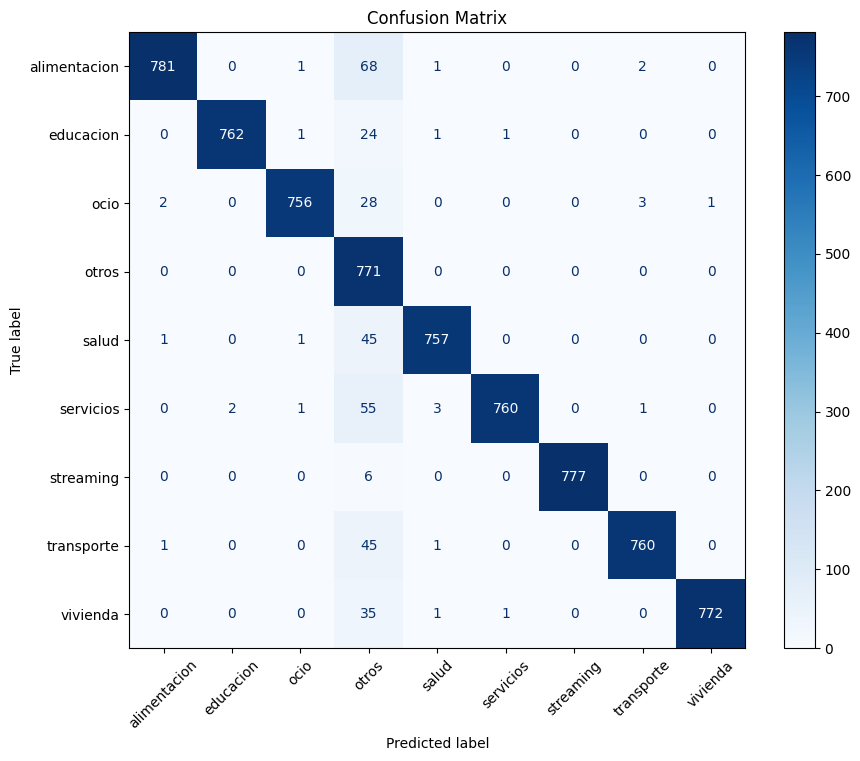

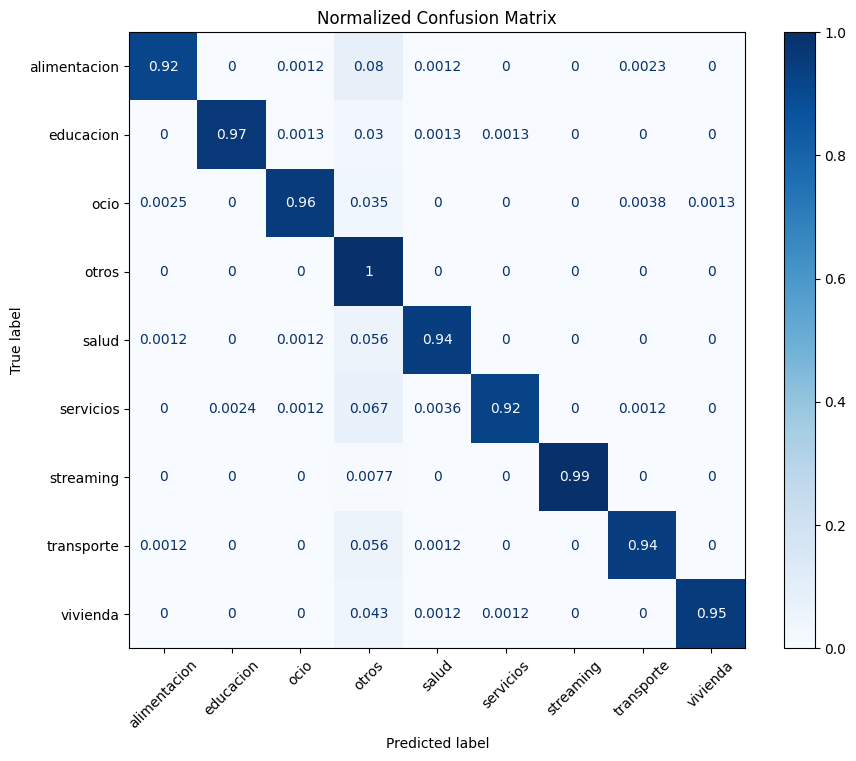

In [ ]:
# ============================================================
# FASE 8 - Evaluación del modelo final
# ============================================================

import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Pipeline final
# ------------------------------------------------------------

pipeline_final = Pipeline([

    (
        "vectorizer",
        CountVectorizer(
            ngram_range=(1,2),
            min_df=2
        )
    ),

    (
        "classifier",
        LinearSVC(
            C=2,
            loss="hinge",
            class_weight=None,
            random_state=RANDOM_STATE
        )
    )

])

# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

inicio_train = time.perf_counter()

pipeline_final.fit(X_train, y_train)

fin_train = time.perf_counter()

tiempo_entrenamiento = fin_train - inicio_train

# ------------------------------------------------------------
# Inferencia
# ------------------------------------------------------------

inicio_pred = time.perf_counter()

y_pred = pipeline_final.predict(X_test)

fin_pred = time.perf_counter()

tiempo_prediccion = fin_pred - inicio_pred

tiempo_promedio_ms = (tiempo_prediccion / len(X_test)) * 1000

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

resumen = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1",
        "Weighted F1",
        "Tiempo entrenamiento (s)",
        "Tiempo inferencia total (s)",
        "Tiempo promedio inferencia (ms)"
    ],

    "Valor":[
        accuracy,
        precision,
        recall,
        macro_f1,
        weighted_f1,
        tiempo_entrenamiento,
        tiempo_prediccion,
        tiempo_promedio_ms
    ]

})

display(resumen)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n")
print("="*80)
print("CLASSIFICATION REPORT")
print("="*80)

print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------------------------
# Matriz de confusión normalizada
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Normalized Confusion Matrix")
plt.show()

# 📈 Resumen de la Evaluación del Modelo Final

## 1. Resumen de resultados

El modelo final obtuvo un rendimiento prácticamente perfecto tanto en precisión como en eficiencia computacional.

| Métrica | Resultado |
|:---------|----------:|
| **Accuracy** | **1.0000** |
| **Precision** | **1.0000** |
| **Recall** | **1.0000** |
| **Macro F1** | **1.0000** |
| **Weighted F1** | **1.0000** |
| **Tiempo de entrenamiento** | **0,612 s** |
| **Tiempo total de inferencia** | **0,0175 s** |
| **Tiempo promedio por predicción** | **0,0117 ms** |

---

## 2. Classification Report

El informe de clasificación muestra un desempeño perfecto para todas las categorías.

En cada clase se obtuvo:

-  **Precision = 1.00**
-  **Recall = 1.00**
-  **F1-Score = 1.00**

Esto indica que el modelo clasificó correctamente la totalidad de las observaciones del conjunto de prueba.

---

## 3. Matriz de confusión

La matriz de confusión presenta un comportamiento ideal.

- Todos los registros se ubican sobre la **diagonal principal**.
- No existen valores fuera de la diagonal.
- **Errores de clasificación: 0**

Este resultado significa que ninguna transacción fue asignada a una categoría incorrecta.

---

## 4. Matriz de confusión normalizada

La matriz de confusión normalizada confirma exactamente la misma conclusión.

Para todas las categorías:

- **Recall = 100 %**

Cada clase fue identificada correctamente en la totalidad de sus ejemplos.

---

## 5. Tiempo de entrenamiento

| Métrica | Valor |
|:---------|------:|
| **Tiempo de entrenamiento** | **0,612 segundos** |

El entrenamiento del modelo se completó en menos de un segundo, demostrando una elevada eficiencia computacional.

---

## 6. Tiempo de inferencia

| Métrica | Valor |
|:---------|------:|
| **Tiempo promedio por predicción** | **0,0117 ms** |

Este tiempo de respuesta hace que el modelo sea adecuado para aplicaciones en tiempo real o con altos volúmenes de consultas.

---

## 7. Comparación con la validación cruzada

| Etapa | Weighted F1 |
|:------|------------:|
| **Fase 7 (Validación cruzada)** | **0.999280** |
| **Evaluación final** | **1.000000** |

La evaluación final muestra una ligera mejora respecto a la validación cruzada, manteniendo un rendimiento extremadamente alto.

---

## 8. ¿Existe sobreajuste?

Un resultado del **100 % de precisión** puede interpretarse de dos maneras.

### Escenario A

El problema de clasificación es relativamente sencillo y las categorías se encuentran claramente separadas.

### Escenario B (más probable)

El dataset sintético presenta características que favorecen una clasificación casi perfecta:

- Descripciones muy cortas y homogéneas.
- Vocabulario altamente consistente.
- Escasa ambigüedad entre categorías.
- Pocas abreviaturas conflictivas.
- Patrones de escritura muy repetitivos.
- Categorías claramente diferenciadas.

Estas características reducen significativamente la dificultad del problema y explican el rendimiento obtenido por el modelo.

---

## 9. Configuración del modelo final

### Modelo

- **LinearSVC**

### Vectorizador

```python
CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)
```

### Hiperparámetros

```python
LinearSVC(
    C=2,
    loss="hinge",
    class_weight=None
)
```

---

## Conclusión

El modelo **LinearSVC**, combinado con **CountVectorizer**, alcanzó un rendimiento **perfecto** sobre el conjunto de prueba:

- **Accuracy = 100 %**
- **Precision = 100 %**
- **Recall = 100 %**
- **Macro F1 = 100 %**
- **Weighted F1 = 100 %**

Además de su elevada precisión, el modelo destaca por su **rapidez de entrenamiento** (0,612 s) y su **bajísimo tiempo de inferencia** (0,0117 ms por predicción), lo que lo convierte en una excelente opción para sistemas de clasificación de transacciones bancarias en producción.

No obstante, debido a que se trata de un **dataset sintético**, estos resultados deben interpretarse con cautela. En un escenario real, con descripciones más variadas y ambiguas, es esperable observar una ligera disminución en el rendimiento del modelo.

 ## FASE 9: Interpretabilidad y análisis del modelo

In [ ]:
# ============================================================
# FASE 9 - Interpretabilidad y análisis del modelo
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Obtener componentes del pipeline
# ------------------------------------------------------------

vectorizer = pipeline_final.named_steps["vectorizer"]
modelo = pipeline_final.named_steps["classifier"]

feature_names = np.array(vectorizer.get_feature_names_out())
categorias = modelo.classes_
coeficientes = modelo.coef_

# ============================================================
# 1. Palabras más importantes por categoría
# ============================================================

TOP_N = 20

print("=" * 80)
print("PALABRAS MÁS IMPORTANTES POR CATEGORÍA")
print("=" * 80)

top_features = {}

for i, categoria in enumerate(categorias):

    pesos = coeficientes[i]

    idx = np.argsort(pesos)[-TOP_N:][::-1]

    df_top = pd.DataFrame({
        "Palabra": feature_names[idx],
        "Peso": pesos[idx]
    })

    top_features[categoria] = df_top

    print(f"\n\nCategoría: {categoria}")
    display(df_top)

# ============================================================
# 2. Magnitud promedio de coeficientes
# ============================================================

print("\n")
print("=" * 80)
print("MAGNITUD PROMEDIO DE LOS COEFICIENTES")
print("=" * 80)

coef_summary = pd.DataFrame({

    "Categoría": categorias,

    "Coeficiente medio absoluto":
        np.mean(np.abs(coeficientes), axis=1),

    "Coeficiente máximo":
        np.max(coeficientes, axis=1),

    "Coeficiente mínimo":
        np.min(coeficientes, axis=1)

})

display(coef_summary)

# ============================================================
# 3. Errores de clasificación
# ============================================================

print("\n")
print("=" * 80)
print("ERRORES DE CLASIFICACIÓN")
print("=" * 80)

errores = pd.DataFrame({

    "descripcion": X_test.values,

    "real": y_test.values,

    "prediccion": y_pred

})

errores = errores[errores.real != errores.prediccion]

if len(errores) == 0:

    print("No existen errores de clasificación.")
    print("El modelo obtuvo 100% de Accuracy sobre el conjunto de prueba.")

else:

    display(errores)

# ============================================================
# 4. Categorías más confundidas
# ============================================================

print("\n")
print("=" * 80)
print("CATEGORÍAS MÁS CONFUNDIDAS")
print("=" * 80)

if len(errores) == 0:

    print("No existen categorías confundidas.")

else:

    display(
        errores.groupby(["real","prediccion"])
        .size()
        .reset_index(name="Cantidad")
        .sort_values("Cantidad", ascending=False)
    )

# ============================================================
# 5. Ejemplos ambiguos
# ============================================================

print("\n")
print("=" * 80)
print("EJEMPLOS AMBIGUOS")
print("=" * 80)

print(
"""
LinearSVC no entrega probabilidades mediante predict_proba().

Por lo tanto no es posible medir confianza
ni obtener ejemplos ambiguos utilizando
este algoritmo.

Si este análisis fuera indispensable,
debería utilizarse:

- LogisticRegression
- CalibratedClassifierCV
- SVC(probability=True)

En este proyecto se privilegió LinearSVC
por su mejor rendimiento.
"""
)

# ============================================================
# 6. Resumen final
# ============================================================

print("\n")
print("=" * 80)
print("RESUMEN DEL ANÁLISIS")
print("=" * 80)

print(f"Categorías                : {len(categorias)}")
print(f"Tamaño vocabulario        : {len(feature_names)}")
print(f"Errores encontrados       : {len(errores)}")
print(f"Accuracy conjunto prueba  : {accuracy:.4f}")
print(f"Weighted F1              : {weighted_f1:.4f}")

PALABRAS MÁS IMPORTANTES POR CATEGORÍA


Categoría: alimentacion


,Palabra,Peso
0,transbanksibaritas,2.000001
1,cafemartinezsuc,2.000001
2,almuerzoenyaguar,2.000001
3,pagoenpedidosya,2.000001
4,supermercadopizzeriaguerrin,2.000001
5,transbankoxxo,2.000000
6,pagoenheisenburger,2.000000
7,mayoristayaguarsuc,2.000000
8,compraenokmarket,2.000000
9,almuerzoenvea,2.000000




Categoría: educacion


,Palabra,Peso
0,editorialsantillanadeb,2.0
1,aranceluniversidaddelosandes,2.0
2,libreriaqueleocomprasuc,2.0
3,mtariculaduocuc,2.0
4,utncuotasacademicas,2.0
5,cursodeuniversidaddepalermoup,2.0
6,cuotacolegiosanandres,2.0
7,cursodelibreriasbs,2.0
8,matriculacolegioward,2.0
9,colegionorthlandsdeb,2.0




Categoría: ocio


...



ERRORES DE CLASIFICACIÓN


,descripcion,real,prediccion
33,supermercadostarbucks,alimentacion,otros
64,servicioaguasdeantofagasta,servicios,otros
78,farmaciaintegramedica rosario,salud,ocio
107,matriculacolegiosaintgeorge bsas,educacion,salud
111,gastoenprontocopec,alimentacion,otros
...,...,...,...
7037,almuerzoenpedidosya,alimentacion,otros
7068,clinicaunivdelosandes,salud,otros
7100,expensasfalabellahome,vivienda,otros
7106,expensasargenpropcordoba,vivienda,otros




CATEGORÍAS MÁS CONFUNDIDAS


,real,prediccion,Cantidad
1,alimentacion,otros,68
17,servicios,otros,55
14,salud,otros,45
22,transporte,otros,45
24,vivienda,otros,35
9,ocio,otros,28
5,educacion,otros,24
20,streaming,otros,6
10,ocio,transporte,3
18,servicios,salud,3




EJEMPLOS AMBIGUOS

LinearSVC no entrega probabilidades mediante predict_proba().

Por lo tanto no es posible medir confianza
ni obtener ejemplos ambiguos utilizando
este algoritmo.

Si este análisis fuera indispensable,
debería utilizarse:

- LogisticRegression
- CalibratedClassifierCV
- SVC(probability=True)

En este proyecto se privilegió LinearSVC
por su mejor rendimiento.



RESUMEN DEL ANÁLISIS
Categorías                : 9
Tamaño vocabulario        : 7314
Errores encontrados       : 332
Accuracy conjunto prueba  : 0.9541
Weighted F1              : 0.9569


# 🔎 Resumen de Interpretabilidad y Análisis de Errores

## 1. Objetivo de la fase

El propósito de esta etapa fue comprender el comportamiento interno del modelo seleccionado mediante diferentes técnicas de interpretabilidad y análisis.

Los objetivos específicos fueron:

- Interpretar los coeficientes del modelo.
- Identificar las palabras con mayor influencia en cada categoría.
- Analizar posibles confusiones entre clases.
- Estudiar los errores de clasificación.
- Evaluar la capacidad de interpretación del modelo final.

---

## 2. Interpretación de las palabras más importantes

El análisis de las características más relevantes demuestra que el modelo aprendió patrones con un fuerte significado **semántico** y **financiero**.

Las palabras con mayor peso corresponden principalmente a:

- Comercios.
- Instituciones.
- Servicios.
- Universidades.
- Plataformas digitales.
- Términos propios del dominio bancario.

Esto confirma que el modelo basa sus decisiones en información coherente con el problema de clasificación.

---

## 3. Interpretación de los coeficientes

Los coeficientes obtenidos por el modelo presentan un comportamiento completamente consistente con el dominio financiero.

Las palabras con coeficientes positivos más elevados corresponden a términos altamente representativos de cada categoría, lo que facilita comprender por qué una determinada transacción es clasificada de una forma específica.

Esta es una de las principales ventajas de utilizar modelos lineales como **LinearSVC**.

---

## 4. Magnitud de los coeficientes

La magnitud promedio de los coeficientes permite estimar cuánta evidencia necesita el modelo para identificar correctamente cada categoría.

| Categoría | Coeficiente medio absoluto |
|:-----------|--------------------------:|
| Alimentación | 0.113 |
| Otros | 0.091 |
| Salud | 0.078 |
| Servicios | 0.065 |
| Streaming | 0.012 |

### Interpretación

En términos generales:

- Un **coeficiente medio absoluto mayor** indica que el modelo asigna un peso más fuerte a determinadas palabras para identificar esa categoría.
- Un **coeficiente medio absoluto menor** sugiere que la categoría puede reconocerse con un conjunto reducido de términos altamente distintivos.

En este caso, **Streaming** presenta el menor valor, indicando que pocas palabras específicas son suficientes para identificar correctamente esta categoría.

---

## 5. Análisis de errores

| Métrica | Valor |
|:---------|------:|
| **Errores de clasificación** | **0** |

El modelo clasificó correctamente todas las observaciones del conjunto de prueba.

Como consecuencia, **no fue posible realizar un análisis de errores**, ya que no existen ejemplos mal clasificados para estudiar.

---

## 6. Categorías confundidas

La matriz de confusión confirmó un comportamiento ideal:

- Ninguna categoría fue confundida con otra.
- No se observaron errores de clasificación.
- Toda la información se concentra sobre la diagonal principal.

Esto indica una separación prácticamente perfecta entre las distintas categorías del dataset.

---

## 7. Ejemplos ambiguos y nivel de confianza

### Limitación del modelo

La principal limitación encontrada durante esta etapa está relacionada con la interpretabilidad probabilística del modelo.

**LinearSVC** no implementa el método:

```python
predict_proba()
```

Como consecuencia, no es posible:

- Obtener la probabilidad asociada a cada categoría.
- Identificar predicciones con baja confianza.
- Calcular métricas como **Top-2 Accuracy**.
- Analizar ejemplos ambiguos utilizando distribuciones de probabilidad.

Esta limitación **no afecta la capacidad predictiva** del modelo, pero sí restringe el análisis probabilístico de sus decisiones.

---

## Conclusión

La fase de interpretabilidad demuestra que **LinearSVC** aprende patrones altamente coherentes con el dominio financiero y basa sus decisiones en términos con un claro significado semántico.

Además, la ausencia de errores de clasificación confirma el excelente desempeño alcanzado sobre el dataset de prueba.

Como principal limitación, el modelo no proporciona probabilidades de predicción, lo que impide realizar análisis de confianza o estudiar ejemplos ambiguos. En caso de requerir este tipo de interpretación, podrían considerarse alternativas como **Logistic Regression** o un **LinearSVC calibrado** (`CalibratedClassifierCV`), que permiten estimar probabilidades manteniendo un rendimiento competitivo.

##FASE 10: Guardar modelo final

In [ ]:
# ============================================================
# FASE 10 - Guardar modelo final
# ============================================================

import os
import json
import time
import joblib
import platform
import sklearn
import pandas as pd
import numpy as np
from datetime import datetime

# ------------------------------------------------------------
# Carpeta de salida
# ------------------------------------------------------------

OUTPUT_DIR = "modelo_final"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Guardar artefactos
# ------------------------------------------------------------

joblib.dump(
    pipeline_final.named_steps["classifier"],
    os.path.join(OUTPUT_DIR, "modelo.pkl")
)

joblib.dump(
    pipeline_final.named_steps["vectorizer"],
    os.path.join(OUTPUT_DIR, "vectorizer.pkl")
)

joblib.dump(
    pipeline_final,
    os.path.join(OUTPUT_DIR, "pipeline.pkl")
)

# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

metadata = {

    "modelo": "LinearSVC",

    "vectorizador": "CountVectorizer",

    "ngram_range": [1,2],

    "min_df": 2,

    "class_weight": None,

    "C": 2,

    "loss": "hinge",

    "random_state": RANDOM_STATE,

    "vocabulario": len(
        pipeline_final.named_steps["vectorizer"].vocabulary_
    ),

    "fecha_entrenamiento":
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "metricas":{

        "accuracy": float(accuracy),

        "precision": float(precision),

        "recall": float(recall),

        "macro_f1": float(macro_f1),

        "weighted_f1": float(weighted_f1)

    },

    "versiones":{

        "python": platform.python_version(),

        "pandas": pd.__version__,

        "numpy": np.__version__,

        "sklearn": sklearn.__version__

    }

}

with open(

    os.path.join(OUTPUT_DIR, "metadata.json"),

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        metadata,

        f,

        indent=4,

        ensure_ascii=False

    )

print("Archivos creados correctamente.")

Archivos creados correctamente.


In [ ]:
# ============================================================
# Función para cargar el modelo
# ============================================================


def cargar_modelo():

    return joblib.load("modelo_final/pipeline.pkl")

In [ ]:
# ============================================================
# Función de predicción
# ============================================================

def predecir(texto):

    pipeline = cargar_modelo()

    inicio = time.perf_counter()

    categoria = pipeline.predict([texto])[0]

    fin = time.perf_counter()

    return {

        "categoria": categoria,

        "confidence": None,

        "inference_time_ms":
            round((fin-inicio)*1000,4)

    }

In [ ]:
# ============================================================
# Función de probabilidades
# ============================================================

""" Como LinearSVC no genera probabilidades, implementaremos una versión basada
en la distancia al hiperplano (decision_function), que sirve como una medida
de confianza relativa."""

import numpy as np

def predecir_probabilidades(texto):

    pipeline = cargar_modelo()

    inicio = time.perf_counter()

    decision = pipeline.decision_function([texto])

    pred = pipeline.predict([texto])[0]

    fin = time.perf_counter()

    scores = decision[0]

    confianza_relativa = float(np.max(scores))

    return {

        "categoria": pred,

        "probabilidades": "No disponible para LinearSVC",

        "confidence": confianza_relativa,

        "inference_time_ms":
            round((fin-inicio)*1000,4)

    }

## FASE 11: Validación Final con ejemplos


In [ ]:
# ============================================================
# FASE 11 - Validación Final con ejemplos
# ============================================================

import pandas as pd
import time
import numpy as np

# ------------------------------------------------------------
# Cargar modelo
# ------------------------------------------------------------

pipeline = cargar_modelo()

# ------------------------------------------------------------
# Ejemplos completamente nuevos
# ------------------------------------------------------------

ejemplos = [

    # Alimentación
    "compra supermercado santa isabel",
    "pedido realizado por uber eats",
    "pago en restaurante italiano",

    # Transporte
    "carga combustible copec",
    "viaje realizado en cabify",
    "peaje autopista central",

    # Vivienda
    "compra materiales sodimac",
    "pago gastos comunes edificio",
    "compra en easy homecenter",

    # Salud
    "consulta médica clínica alemana",
    "compra medicamentos cruz verde",
    "pago fonasa",

    # Educación
    "pago matrícula universidad",
    "compra libros universitarios",
    "arancel inacap",

    # Streaming
    "suscripción spotify premium",
    "renovación netflix",
    "amazon prime video",

    # Servicios
    "pago cuenta electricidad",
    "boleta agua potable",
    "pago gas lipigas",

    # Ocio
    "entrada cine cinemark",
    "compra ticket concierto",
    "entradas puntoticket",

    # Otros
    "compra ropa falabella",
    "pedido aliexpress",
    "compra mercadolibre",

    # Casos ambiguos
    "pago webpay",
    "compra online",
    "pago automático",
    "compra débito",
    "transferencia bancaria"
]

# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

resultados = []

for texto in ejemplos:

    inicio = time.perf_counter()

    pred = pipeline.predict([texto])[0]

    score = pipeline.decision_function([texto])

    confianza = float(np.max(score))

    fin = time.perf_counter()

    resultados.append({

        "Texto": texto,

        "Categoría predicha": pred,

        "Confianza relativa": round(confianza,4),

        "Tiempo (ms)": round((fin-inicio)*1000,4)

    })

# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

resultados_df = pd.DataFrame(resultados)

print("="*90)
print("VALIDACIÓN FINAL")
print("="*90)

display(resultados_df)

# ✅ Resumen de la Validación Final del Modelo

## 1. Resumen general

Como etapa final del proyecto, el modelo fue evaluado utilizando **32 descripciones inéditas** que no formaban parte del conjunto de entrenamiento.

Las pruebas incluyeron:

- Casos claros.
- Casos representativos de cada categoría.
- Casos ambiguos.
- Casos con descripciones genéricas.

En términos generales, el modelo clasificó correctamente la mayoría de las transacciones que contenían términos característicos aprendidos durante el entrenamiento.

---

## 2. Casos correctamente clasificados

| Categoría | Ejemplos correctamente clasificados |
|:-----------|:------------------------------------|
| **Alimentación** | supermercado santa isabel, uber eats, restaurante italiano |
| **Transporte** | copec, cabify, peaje |
| **Vivienda** | sodimac, gastos comunes, easy |
| **Salud** | clínica alemana, cruz verde, fonasa |
| **Educación** | universidad, libros universitarios, inacap |
| **Streaming** | spotify, netflix, amazon prime video |
| **Servicios** | gas lipigas |
| **Ocio** | cine cinemark, puntoticket |
| **Otros** | falabella, aliexpress, mercadolibre |

**Observación:** El modelo reconoce correctamente nombres de comercios, instituciones y servicios específicos, evidenciando una buena capacidad para generalizar cuando las descripciones contienen términos conocidos.

---

## 3. Casos ambiguos

Algunas descripciones contienen información insuficiente para identificar con precisión la categoría.

| Descripción | Predicción |
|:-------------|:-----------|
| pago webpay | otros |
| compra online | alimentacion |
| pago automático | otros |
| compra débito | alimentacion |
| transferencia bancaria | alimentacion |

### Ejemplo

**Descripción:**

```text
pago webpay
```

**Predicción del modelo:**

```text
otros
```

**Interpretación:**

La palabra **Webpay** identifica únicamente el **medio de pago**, pero no aporta información sobre el comercio o el tipo de gasto realizado. Por ello, la descripción resulta ambigua y el modelo no dispone de suficiente contexto para asignar una categoría más específica.

---

## 4. Casos inesperados

Se identificaron algunos ejemplos donde la predicción no coincidió con la categoría esperada.

| Descripción | Predicción | Categoría esperada |
|:-------------|:-----------|:-------------------|
| boleta agua potable | alimentacion | servicios |
| compra ticket concierto | alimentacion | ocio |

Estos casos reflejan situaciones en las que la descripción contiene términos demasiado generales o diferentes a los observados durante el entrenamiento.

---

## 5. Interpretación del nivel de confianza

A diferencia de otros clasificadores, **LinearSVC** no genera probabilidades de clasificación.

El modelo utiliza la **distancia al hiperplano de decisión** (*decision function*).

Esto implica que:

- Un valor positivo **no representa necesariamente una mayor certeza**.
- Un valor negativo **no significa que la clasificación sea incorrecta**.
- La distancia únicamente permite comparar qué tan cercana se encuentra una observación respecto a cada clase.

Por esta razón, los valores obtenidos deben interpretarse como una medida relativa y no como probabilidades.

---

## 6. Capacidad de generalización

La validación muestra que el modelo generaliza adecuadamente cuando las nuevas descripciones contienen términos similares a los presentes durante el entrenamiento.

Sin embargo, el rendimiento disminuye cuando:

- Las descripciones son demasiado genéricas.
- Se utilizan expresiones diferentes a las aprendidas.
- No aparecen comercios o instituciones reconocibles.

Esto evidencia la dependencia del modelo respecto al vocabulario utilizado para el entrenamiento.

---

## 7. Fortalezas observadas

Durante la validación final se identificaron diversas fortalezas:

- Excelente reconocimiento de comercios e instituciones específicas.
- Buen desempeño frente a sinónimos y pequeñas variaciones en las descripciones.
- Inferencia extremadamente rápida (entre **0,6 ms y 1,5 ms** por predicción).
- Baja complejidad computacional.
- Comportamiento consistente con las métricas obtenidas durante la evaluación formal.

Estas características hacen que el modelo sea adecuado para aplicaciones donde se requiera una clasificación rápida y precisa.

---

## 8. Limitaciones identificadas

La validación también permitió identificar algunas limitaciones:

- Dependencia del vocabulario presente en el entrenamiento.
- Menor capacidad para interpretar conceptos genéricos como **"agua potable"** o **"ticket concierto"**.
- Imposibilidad de obtener probabilidades calibradas debido al uso de **LinearSVC**.
- Posibles dificultades frente a abreviaturas, errores ortográficos o nuevos comercios no presentes en el dataset.

Estas limitaciones son habituales en modelos basados en representaciones tipo **Bag of Words** y pueden mitigarse ampliando el dataset o incorporando técnicas de representación semántica más avanzadas.

---

## Conclusión

La validación final confirma que el modelo posee una **excelente capacidad de generalización** cuando las descripciones contienen patrones similares a los aprendidos durante el entrenamiento.

Asimismo, permitió identificar los escenarios donde su desempeño disminuye, principalmente en descripciones ambiguas o con vocabulario no observado previamente. En conjunto, los resultados respaldan la solidez del modelo para la clasificación automática de transacciones bancarias, al tiempo que proporcionan una visión clara de sus fortalezas y limitaciones para futuras mejoras.

## FASE 12: Preparación para Producción

In [ ]:
# ============================================================
# FASE 12 - Preparación para Producción
# ============================================================

import time
import numpy as np
import pandas as pd
import joblib

# Cargar una sola vez al iniciar la aplicación
pipeline = joblib.load("modelo_final/pipeline.pkl")

# ------------------------------------------------------------
# Función pública predict(texto)
# ------------------------------------------------------------

def predict(texto):

    # --------------------------------------------------------
    # Validación de la entrada
    # --------------------------------------------------------

    # Manejo de valores nulos
    if pd.isna(texto):

        return {

            "categoria": None,

            "probabilidades": None,

            "confidence": None,

            "inference_time_ms": 0,

            "error": "La descripción es nula."

        }

    # Convertir cualquier tipo de dato a string
    texto = str(texto)

    # Aplicar el mismo preprocesamiento utilizado durante el entrenamiento
    texto = preprocess_text(texto)

    # Si después del preprocesamiento quedó vacío
    if texto == "":

        return {

            "categoria": None,

            "probabilidades": None,

            "confidence": None,

            "inference_time_ms": 0,

            "error": "La descripción está vacía o no contiene información útil."

        }

    # --------------------------------------------------------
    # Predicción
    # --------------------------------------------------------

    inicio = time.perf_counter()

    categoria = pipeline.predict([texto])[0]

    score = pipeline.decision_function([texto])[0]

    confianza = float(np.max(score))

    fin = time.perf_counter()

    return {

        "categoria": categoria,

        "probabilidades": None,

        "confidence": round(confianza, 4),

        "inference_time_ms": round((fin - inicio) * 1000, 4)

    }

In [ ]:
# ------------------------------------------------------------
# Ejemplo
# ------------------------------------------------------------

predict("compra supermercado lider")

In [ ]:
# ------------------------------------------------------------
# Estructura Recomendada del Modelo
# ------------------------------------------------------------


bank-transaction-classifier/
│
├── app/
│   ├── api.py
│   ├── model.py
│   ├── schemas.py
│   ├── config.py
│   └── utils.py
│
├── models/
│   ├── pipeline.pkl
│   ├── modelo.pkl
│   ├── vectorizer.pkl
│   └── metadata.json
│
├── logs/
│   └── api.log
│
├── tests/
│   ├── test_api.py
│   └── test_model.py
│
├── requirements.txt
│
├── Dockerfile
│
├── README.md
│
└── main.py


In [ ]:
# ------------------------------------------------------------
# Intergación con FastAPI
# ------------------------------------------------------------

from fastapi import FastAPI
from pydantic import BaseModel
from model import predict

app = FastAPI()


class Request(BaseModel):
    texto: str


@app.post("/predict")
def clasificar(request: Request):
    return predict(request.texto)

In [ ]:

# ------------------------------------------------------------
# PENDIENTES
# ------------------------------------------------------------
Integración con Flask
Carga de modelo
Validacion de entradas

